In [1]:

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import geopandas as gpd
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from geopy.distance import geodesic
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Geohash decode helper
try:
    import geohash as gh_lib
    def decode_gh(gh_str):
        r = gh_lib.decode(gh_str)
        return float(r[0]), float(r[1])
    def truncate_gh(gh_str, precision=5):
        return str(gh_str)[:precision]
except Exception:
    import pygeohash as _pgh
    def decode_gh(gh_str):
        r = _pgh.decode(gh_str)
        return float(r[0]), float(r[1])
    def truncate_gh(gh_str, precision=5):
        return str(gh_str)[:precision]

print("All imports OK ✓")


All imports OK ✓


In [2]:

# ── File paths ─────────────────────────────────────────────────────────────────
DATA_DIR   = '../../data/activity/'
VENUES_DIR = '../../data/venues/tac-list/'
GEO_DIR    = '../../data/geo/regions/'

STOPS_PATH  = DATA_DIR + 'venue_stops.csv'
HOMES_PATH  = DATA_DIR + 'venues_homes.csv'
DENOMS_PATH = DATA_DIR + 'toronto_month_denoms.csv'
TAC_PATH    = VENUES_DIR + 'venues_TAC_EDDIT V2 March 12.csv'
GEO_PATH    = GEO_DIR + 'GTA_CSD.gpkg'

# ── Output directory ───────────────────────────────────────────────────────────
OUT_DIR = '../../data/prelim/report_260422/'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Year colour palette ────────────────────────────────────────────────────────
YEAR_COLORS = {2023: '#3498db', 2024: '#2ecc71', 2025: '#e74c3c'}

# ── Report figure style defaults ──────────────────────────────────────────────
REPORT_STYLE = dict(style='whitegrid')
sns.set_theme(**REPORT_STYLE)

print(f"Constants set ✓")
print(f"  Output → {os.path.abspath(OUT_DIR)}")


Constants set ✓
  Output → /home/aniket/Programming/eddit-tac/data/prelim/report_260422



# EDDIT Toronto Arts Venues — Report Figures (April 2025)

**Data coverage:** February 2023 – December 2025 (~34 months) | **Venues:** 51 Toronto arts & culture venues

---

## Section 1 — Data Availability

Before presenting any per-venue results it is worth being transparent about the shape and completeness of the underlying dataset. Two figures establish this foundation:

- **fig01** gives a raw count of detected visits city-wide month by month, colour-coded by year, so readers can immediately see seasonal patterns and data gaps.  
- **fig02** is a venue × month presence/absence heatmap — a quick visual audit of which venues have continuous records vs. late entrants or isolated gaps.

> **Key insight:** Most venues have excellent coverage across the full 34-month window; a small cohort entered the dataset later (MUSE Arts Creative Lab, Cedar Ridge). The annual rhythm of visits is visible from year one, with summer peaks and a clear winter trough.


In [3]:

# ── Load data ──────────────────────────────────────────────────────────────────
stops_raw  = pd.read_csv(STOPS_PATH)
homes_raw  = pd.read_csv(HOMES_PATH)
denoms_raw = pd.read_csv(DENOMS_PATH)
tac_raw    = pd.read_csv(TAC_PATH)

# Parse year_month → datetime
for df in (stops_raw, denoms_raw):
    df['year_month'] = pd.to_datetime(df['year_month'].astype(str), format='%Y%m')

# Convenience columns on stops
stops_raw['year']      = stops_raw['year_month'].dt.year
stops_raw['month_num'] = stops_raw['year_month'].dt.month

# Primary working subset (time_period == 'all')
stops_all = stops_raw[stops_raw['time_period'] == 'all'].copy()
homes_all = homes_raw[homes_raw['time_period'] == 'all'].copy()

# Venue lat/lon lookup
venue_loc = tac_raw[['venue_name', 'lat', 'lon']].dropna(subset=['lat', 'lon']).drop_duplicates('venue_name')

# City-wide denominator (time_period == 'all')
denoms_all = denoms_raw[denoms_raw['time_period'] == 'all'].sort_values('year_month').copy()
denoms_all['year'] = denoms_all['year_month'].dt.year

# Venue-level totals (used across multiple sections)
venue_totals = (
    stops_all.groupby('venue_name')[['stop_count', 'unique_devices']]
    .sum()
    .sort_values('stop_count', ascending=False)
    .reset_index()
)
venue_totals['stops_per_device'] = venue_totals['stop_count'] / venue_totals['unique_devices']

print(f"Loaded: {stops_raw.shape[0]:,} stop rows | {homes_raw.shape[0]:,} home rows")
print(f"Venues: {stops_all['venue_name'].nunique()} | "
      f"Date range: {stops_all['year_month'].min().strftime('%b %Y')} → "
      f"{stops_all['year_month'].max().strftime('%b %Y')}")


Loaded: 8,340 stop rows | 64,177 home rows
Venues: 50 | Date range: Feb 2023 → Dec 2025


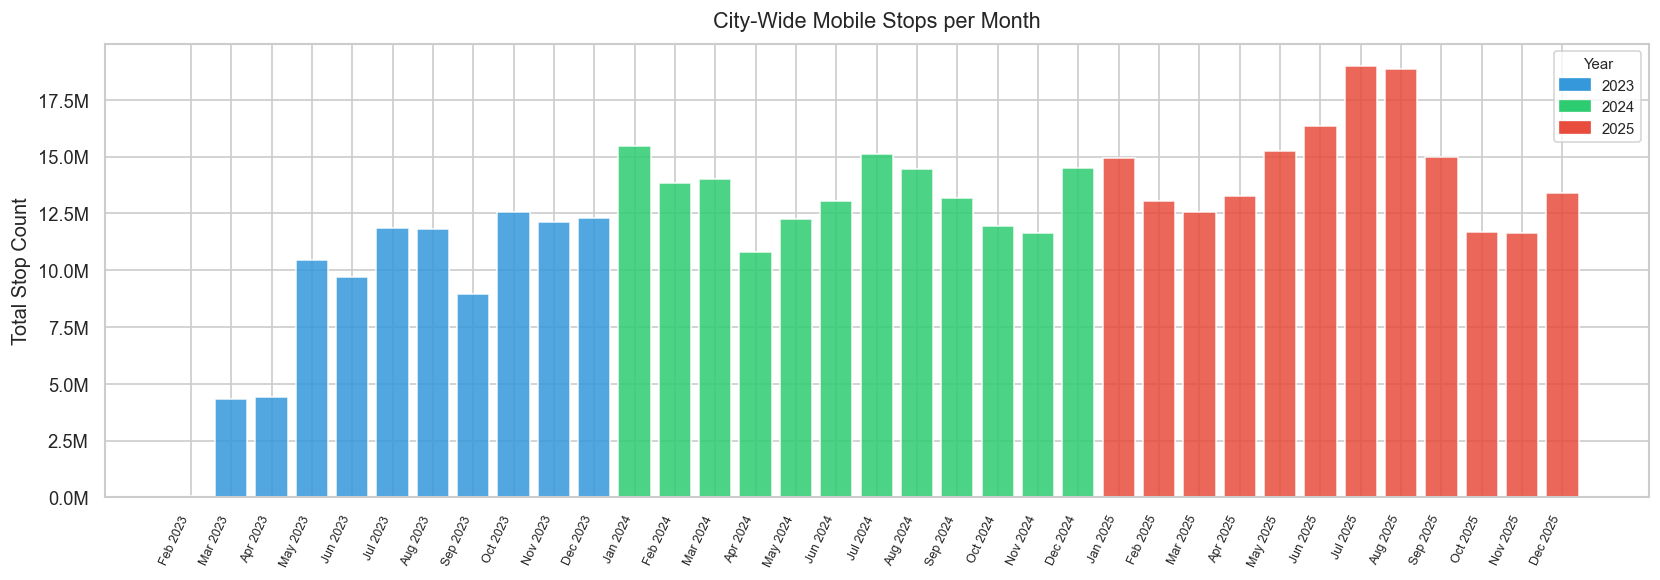

✓ Saved fig01a_city_monthly_stops.png


In [30]:

# ── fig01a_city_monthly_stops — raw stop count per month, colour-coded by year ──
fig, ax = plt.subplots(figsize=(14, 5))

bar_colors = [YEAR_COLORS.get(y, '#95a5a6') for y in denoms_all['year']]
ax.bar(range(len(denoms_all)), denoms_all['total_stop_count'],
       color=bar_colors, alpha=0.85, width=0.8)

ax.set_xticks(range(len(denoms_all)))
ax.set_xticklabels(
    [d.strftime('%b %Y') for d in denoms_all['year_month']],
    rotation=65, ha='right', fontsize=7.5
)
ax.set_ylabel('Total Stop Count')
ax.set_title('City-Wide Mobile Stops per Month', fontsize=13, pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Year legend
handles = [mpatches.Patch(color=c, label=str(yr)) for yr, c in YEAR_COLORS.items()]
ax.legend(handles=handles, title='Year', fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig01a_city_monthly_stops.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig01a_city_monthly_stops.png")


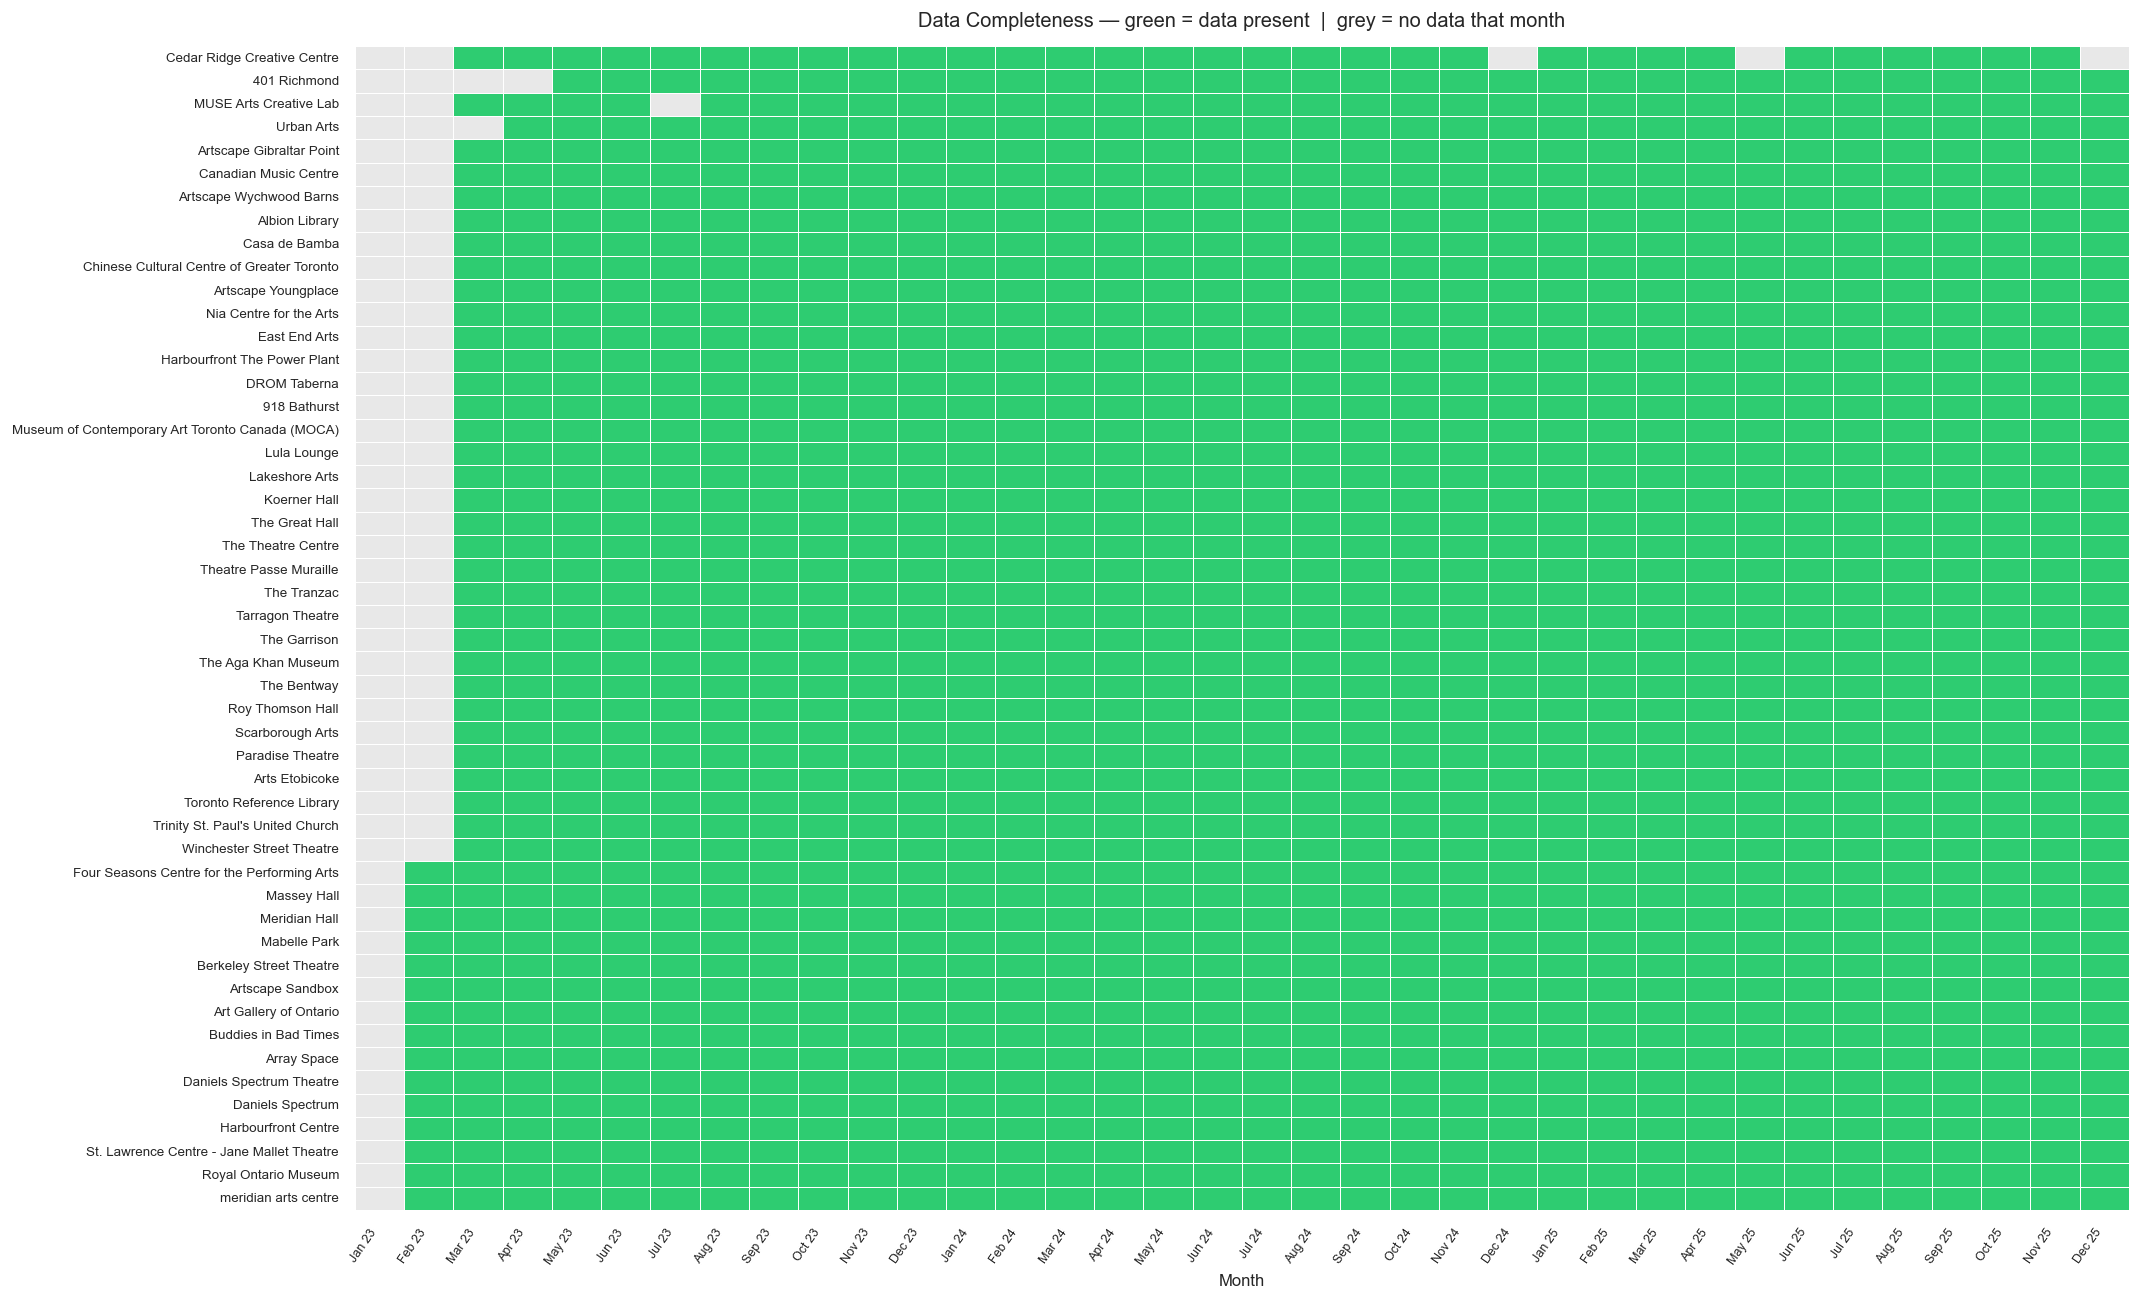

✓ Saved fig01b_data_completeness.png


In [31]:

# ── fig01b_data_completeness — venue × month presence/absence heatmap ───────────
pivot_complete = stops_all.pivot_table(
    index='venue_name', columns='year_month',
    values='stop_count', aggfunc='sum'
)
# Sort venues: most complete first, then alphabetically
complete_pct = pivot_complete.notna().sum(axis=1) / pivot_complete.shape[1] * 100
pivot_complete = pivot_complete.loc[complete_pct.sort_values(ascending=True).index]

# Insert Jan 2023 as empty column (data started Feb 2023)
jan_2023 = pd.Timestamp('2023-01-01')
if jan_2023 not in pivot_complete.columns:
    pivot_complete.insert(0, jan_2023, np.nan)


fig, ax = plt.subplots(figsize=(18, 11))
sns.heatmap(
    pivot_complete.notna().astype(int),
    ax=ax,
    cmap=['#e8e8e8', '#2ecc71'],
    linewidths=0.4, linecolor='white',
    xticklabels=[d.strftime('%b %y') for d in pivot_complete.columns],
    cbar=False
)
ax.set_title('Data Completeness — green = data present  |  grey = no data that month',
             fontsize=12, pad=12)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('')
plt.xticks(rotation=55, ha='right', fontsize=7.5)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig01b_data_completeness.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig01b_data_completeness.png")



---

## Section 2 — Data Distribution

Traffic across venues is starkly unequal — a handful of major institutions account for the lion's share of recorded visits. This section quantifies that inequality and profiles the top performers.

- **fig03** is a cumulative distribution curve showing how quickly total visits concentrate as you move down the venue rankings.  
- **fig04a / fig04b** show the top 15 venues by total stops and unique devices respectively, as clean horizontal bar charts.  
- **fig05** plots normalised monthly visit share for the top 10 venues over the full 34-month window, revealing each venue's seasonal rhythm.

> **Key insight:** The top 6 venues account for roughly half of all recorded stops. The cumulative curve has a pronounced "elbow" around rank 10–15, after which each additional venue contributes diminishing marginal traffic. Despite shared dominance in raw counts, the top 10 venues show strikingly different monthly profiles — some mirror city-wide mobility while others move on their own programming calendar.


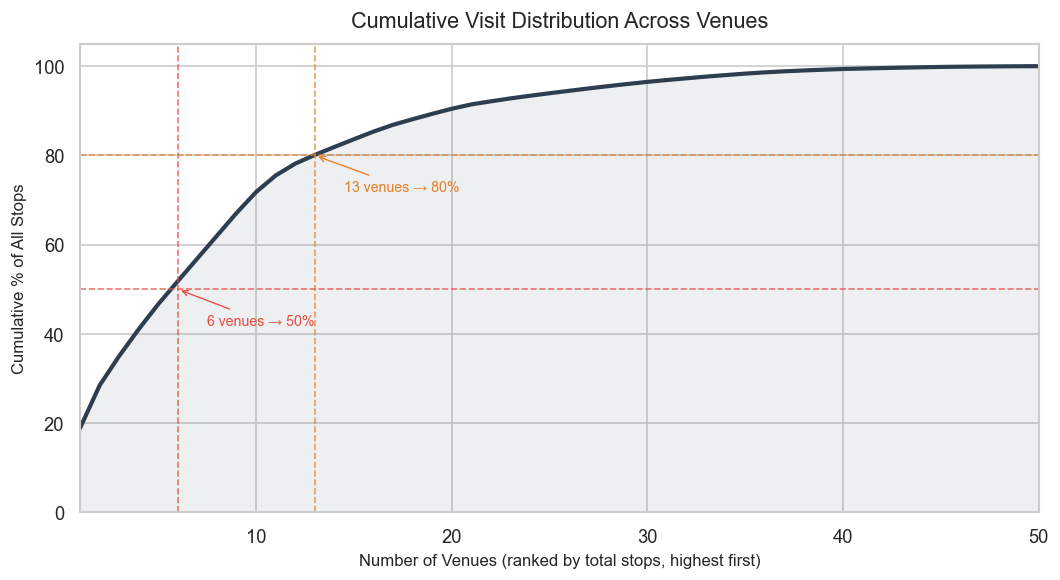

✓ Saved fig02a_cumulative_distribution.png


In [32]:

# ── fig02a_cumulative_distribution — how concentrated is venue traffic? ─────────
cum_stops = venue_totals['stop_count'].cumsum() / venue_totals['stop_count'].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_stops) + 1), cum_stops,
        color='#2c3e50', linewidth=2.5)
ax.fill_between(range(1, len(cum_stops) + 1), cum_stops, alpha=0.08, color='#2c3e50')

# Mark the 50 % and 80 % thresholds
for pct, color in [(50, '#e74c3c'), (80, '#e67e22')]:
    n = (cum_stops < pct).sum() + 1
    ax.axhline(pct, color=color, linestyle='--', linewidth=1.0, alpha=0.75)
    ax.axvline(n, color=color, linestyle='--', linewidth=1.0, alpha=0.75)
    ax.annotate(f'{n} venues → {pct}%',
                xy=(n, pct), xytext=(n + 1.5, pct - 8),
                fontsize=8.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

ax.set_xlabel('Number of Venues (ranked by total stops, highest first)', fontsize=10)
ax.set_ylabel('Cumulative % of All Stops', fontsize=10)
ax.set_title('Cumulative Visit Distribution Across Venues', fontsize=13, pad=10)
ax.set_ylim(0, 105)
ax.set_xlim(1, len(cum_stops))

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig02a_cumulative_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig02a_cumulative_distribution.png")


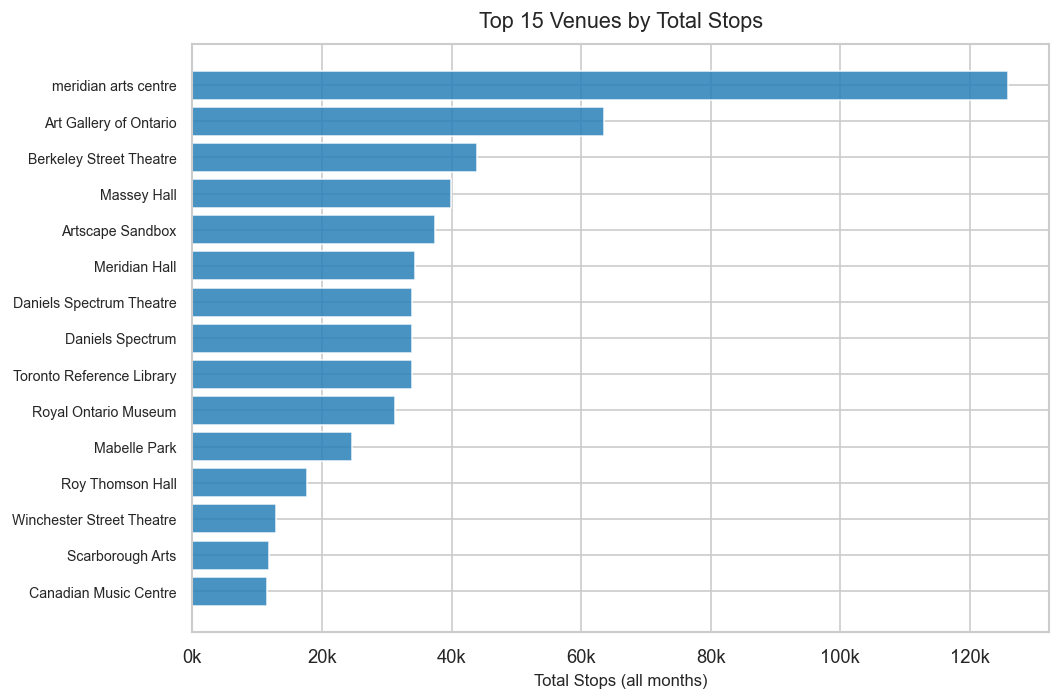

✓ Saved fig02b_top15_total_stops.png


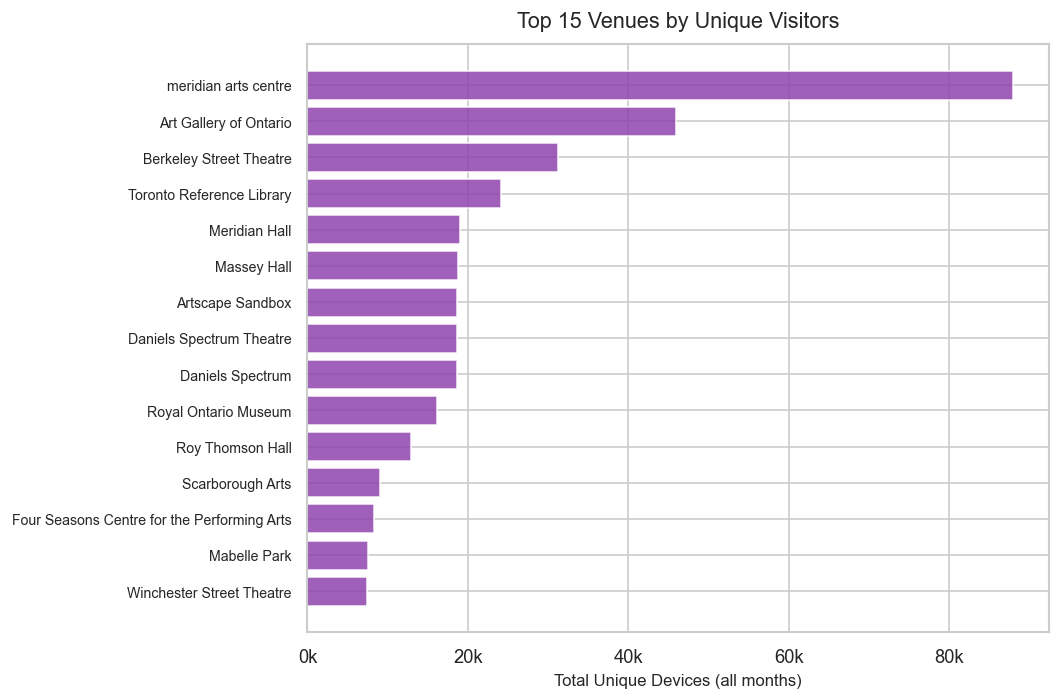

✓ Saved fig02c_top15_unique_devices.png


In [33]:

# ── fig04a — top 15 venues by total stops ─────────────────────────────────────
top15_stops = venue_totals.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_stops['venue_name'][::-1], top15_stops['stop_count'][::-1],
        color='#2980b9', alpha=0.85)
ax.set_xlabel('Total Stops (all months)', fontsize=10)
ax.set_title('Top 15 Venues by Total Stops', fontsize=13, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig02b_top15_total_stops.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig02b_top15_total_stops.png")

# ── fig04b — top 15 venues by unique devices ──────────────────────────────────
top15_devices = venue_totals.sort_values('unique_devices', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_devices['venue_name'][::-1], top15_devices['unique_devices'][::-1],
        color='#8e44ad', alpha=0.85)
ax.set_xlabel('Total Unique Devices (all months)', fontsize=10)
ax.set_title('Top 15 Venues by Unique Visitors', fontsize=13, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig02c_top15_unique_devices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig02c_top15_unique_devices.png")


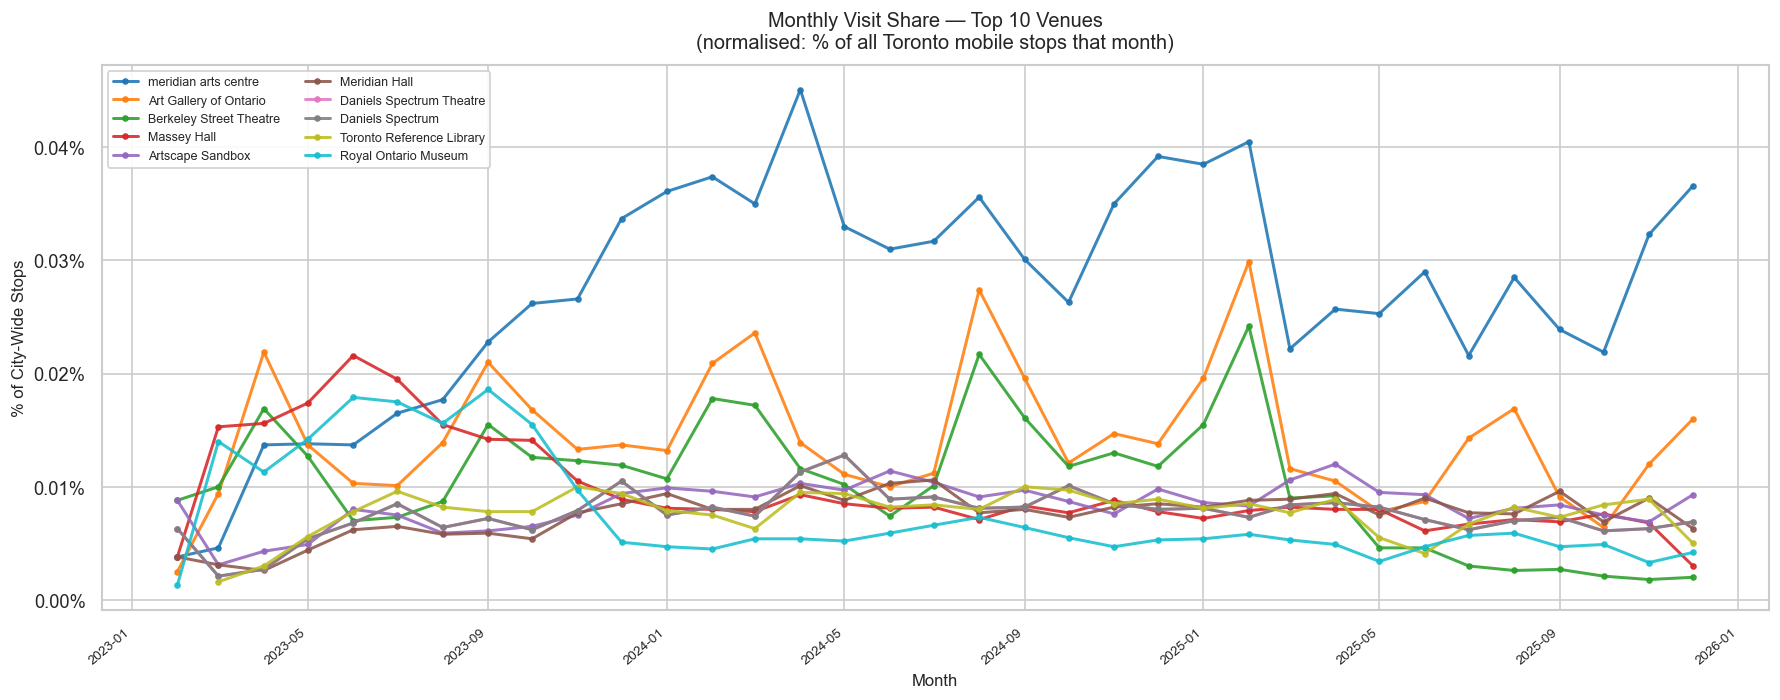

✓ Saved fig02d_top10_monthly_trends.png


In [34]:

# ── fig02d_top10_monthly_trends — normalised stop_prop per month ───────────────
top10_names = venue_totals.head(10)['venue_name'].tolist()
trend_data  = stops_all[stops_all['venue_name'].isin(top10_names)].copy()
trend_pivot = trend_data.pivot_table(
    index='year_month', columns='venue_name', values='stop_prop', aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(15, 6))
palette = sns.color_palette('tab10', 10)

for i, venue in enumerate(top10_names):
    if venue not in trend_pivot.columns:
        continue
    series = trend_pivot[venue].dropna()
    ax.plot(series.index, series * 100,
            marker='o', markersize=3, linewidth=1.8,
            color=palette[i], label=venue, alpha=0.88)

ax.set_title('Monthly Visit Share — Top 10 Venues\n'
             '(normalised: % of all Toronto mobile stops that month)',
             fontsize=12, pad=10)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('% of City-Wide Stops', fontsize=10)
ax.legend(loc='upper left', fontsize=7.5, ncol=2, framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig02d_top10_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig02d_top10_monthly_trends.png")



---

## Section 3 — Temporal Character

Not all venues operate on the same clock. This section separates venues by *when* people visit — weekday vs. weekend, and daytime vs. evening.

- **fig06a** ranks all venues by their weekend fraction, with a reference line at the expected 2/7 share. Venues to the right of that line over-index on weekends.  
- **fig06b** ranks venues by their evening fraction, paired against the 9am–5pm share.

> **Key insight:** A clear bifurcation exists between daytime institutions (libraries, galleries, artist studios) and after-dark performance venues. Evening and weekend heaviness are correlated — the "after-dark arts" cluster is a distinct audience behaviour type.


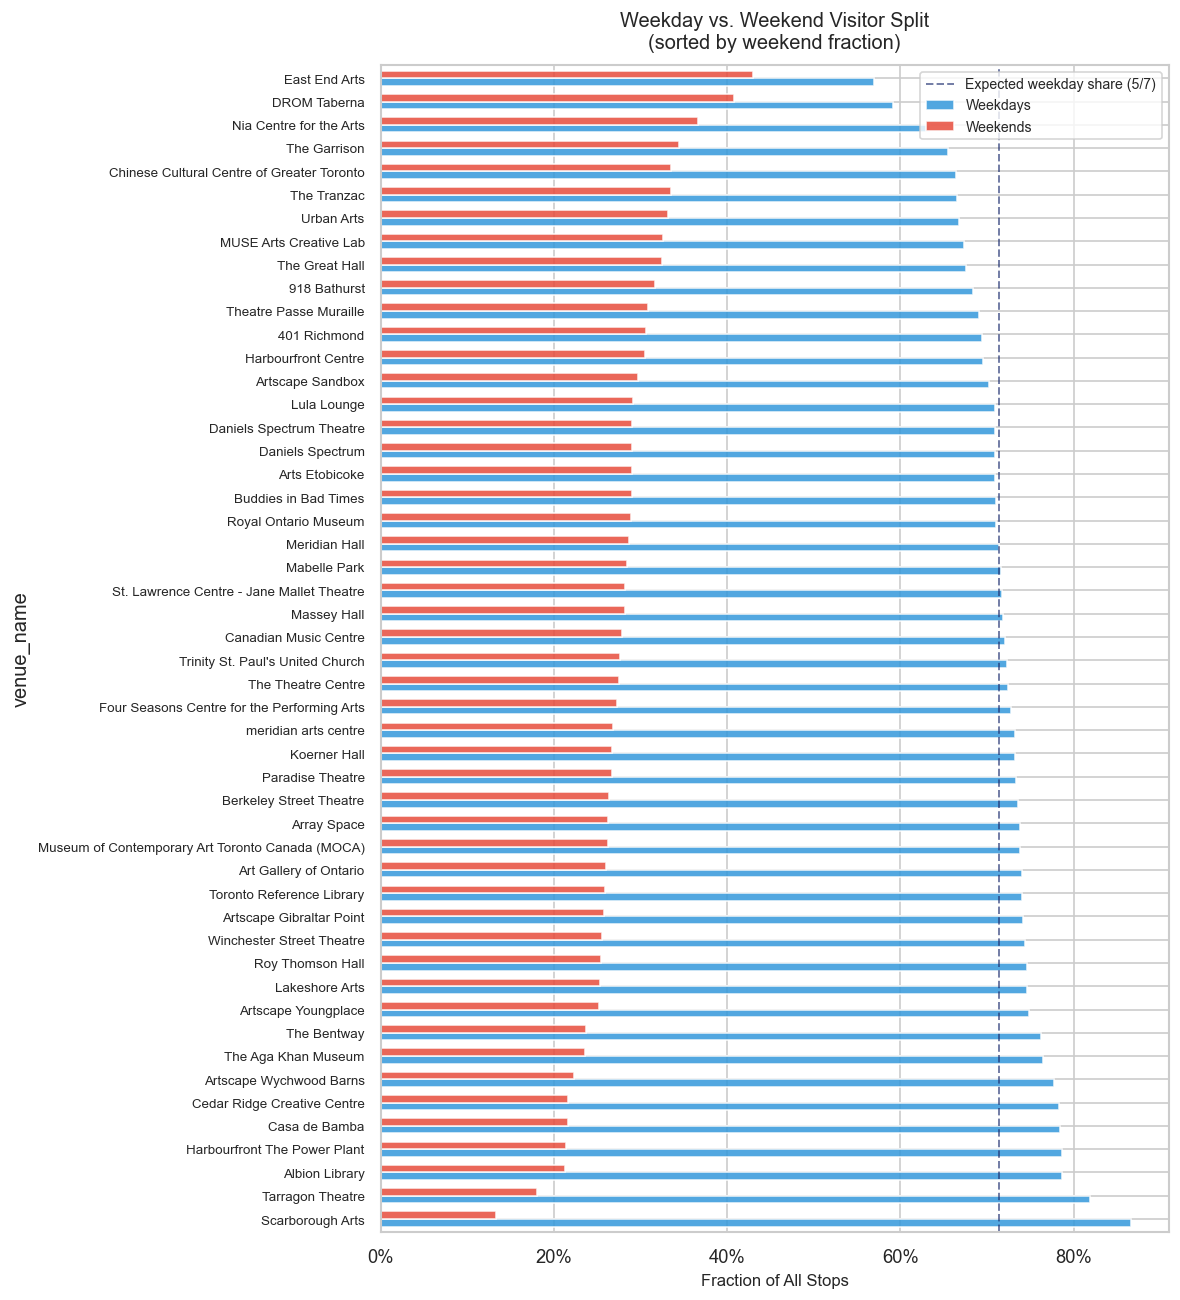

✓ Saved fig03a_weekday_weekend.png


In [35]:

# ── Build per-venue time-period fractions ──────────────────────────────────────
TP_LABELS = {
    'weekdays':  'Weekdays',
    'weekends':  'Weekends',
    'evening':   'Evenings',
    'nine-five': '9am–5pm',
}
all_stops_sum = stops_raw[stops_raw['time_period'] == 'all'].groupby('venue_name')['stop_count'].sum()

period_sums = {
    label: stops_raw[stops_raw['time_period'] == tp].groupby('venue_name')['stop_count'].sum()
    for tp, label in TP_LABELS.items()
}
period_frac = pd.DataFrame(period_sums).div(all_stops_sum, axis=0).fillna(0)

# ── fig06a — weekday vs weekend split, sorted by weekend fraction ──────────────
period_frac_wknd = period_frac.sort_values('Weekends', ascending=True)

fig, ax = plt.subplots(figsize=(10, 11))
period_frac_wknd[['Weekdays', 'Weekends']].plot(
    kind='barh', ax=ax,
    color=['#3498db', '#e74c3c'], alpha=0.85, width=0.65
)
ax.axvline(5/7, color='#1a2a6c', linestyle='--', linewidth=1.2, alpha=0.6,
           label='Expected weekday share (5/7)')
ax.set_xlabel('Fraction of All Stops', fontsize=10)
ax.set_title('Weekday vs. Weekend Visitor Split\n(sorted by weekend fraction)',
             fontsize=12, pad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig03a_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig03a_weekday_weekend.png")


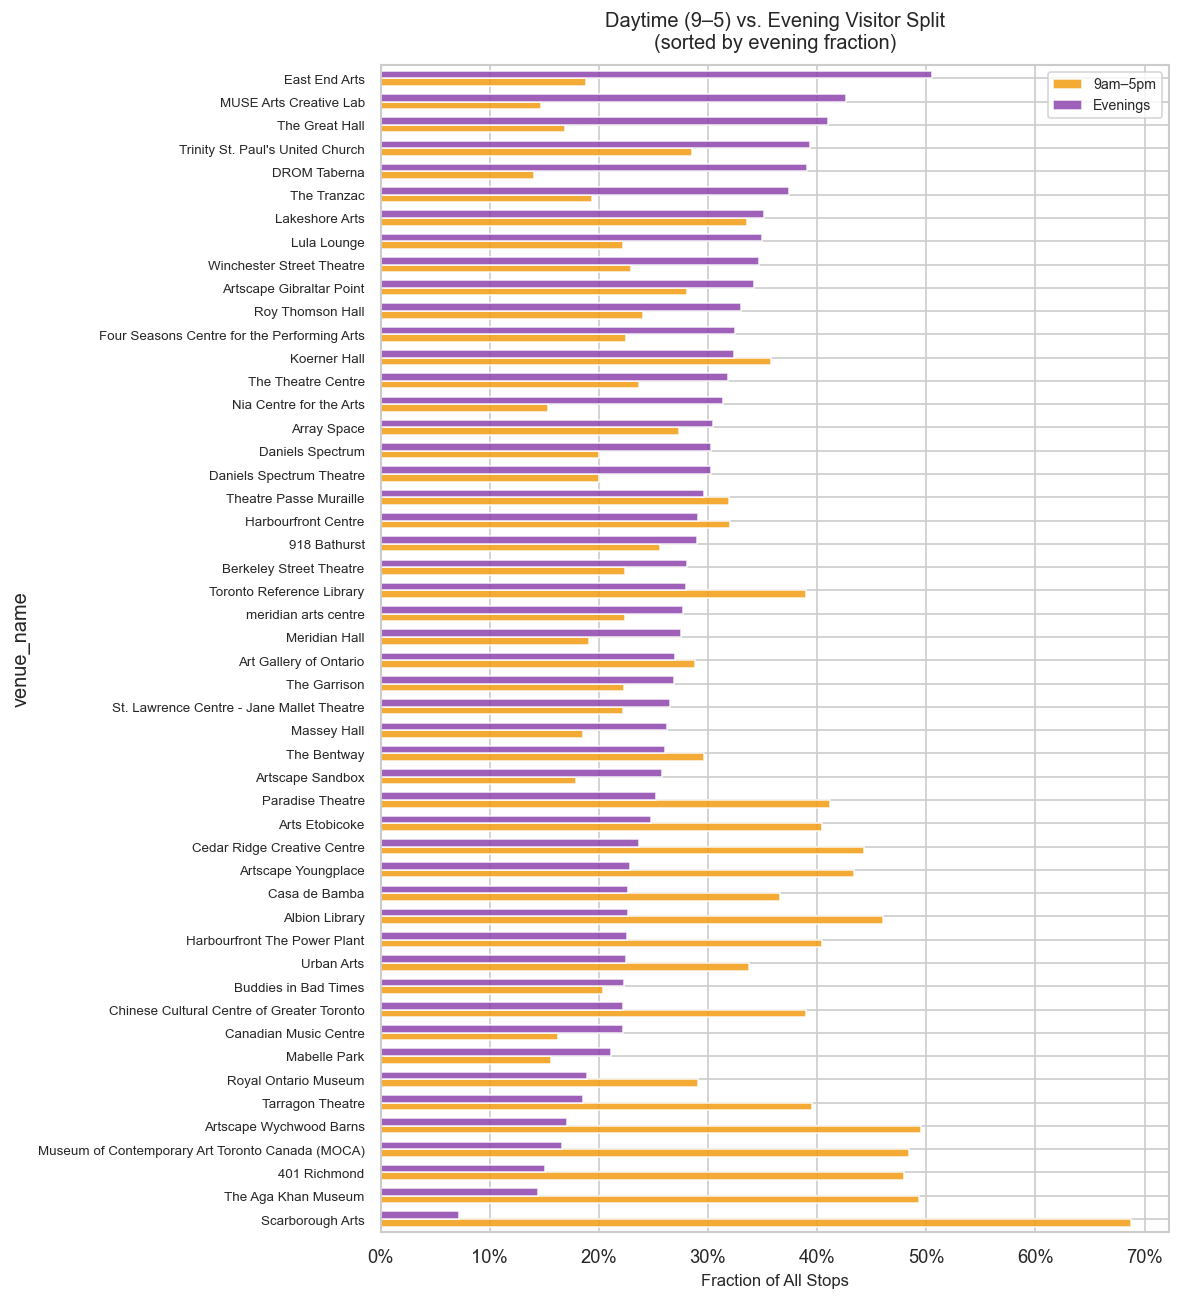

✓ Saved fig03b_daytime_evening.png


In [36]:

# ── fig06b — daytime vs evening split, sorted by evening fraction ─────────────
period_frac_eve = period_frac.sort_values('Evenings', ascending=True)

fig, ax = plt.subplots(figsize=(10, 11))
period_frac_eve[['9am–5pm', 'Evenings']].plot(
    kind='barh', ax=ax,
    color=['#f39c12', '#8e44ad'], alpha=0.85, width=0.65
)
ax.set_xlabel('Fraction of All Stops', fontsize=10)
ax.set_title('Daytime (9–5) vs. Evening Visitor Split\n(sorted by evening fraction)',
             fontsize=12, pad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig03b_daytime_evening.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig03b_daytime_evening.png")



---

## Section 4 — Visitor Frequency

The ratio of total stops to unique devices is a proxy for how often the typical visitor returns. A high ratio indicates a loyal, repeat audience; a low ratio is characteristic of destination or one-time visits.

- **fig07** ranks all venues by stops-per-device, with bucket thresholds used to categorise venues numerically (no qualitative labels). The mean is marked for reference.

> **Key insight:** Most venues fall in the 1.5–3.0 range, meaning a typical visitor returns 1–2 times over the study period. A small group of neighbourhood-anchored venues (Mabelle Park, 918 Bathurst) have ratios above 4, reflecting genuine community regulars.


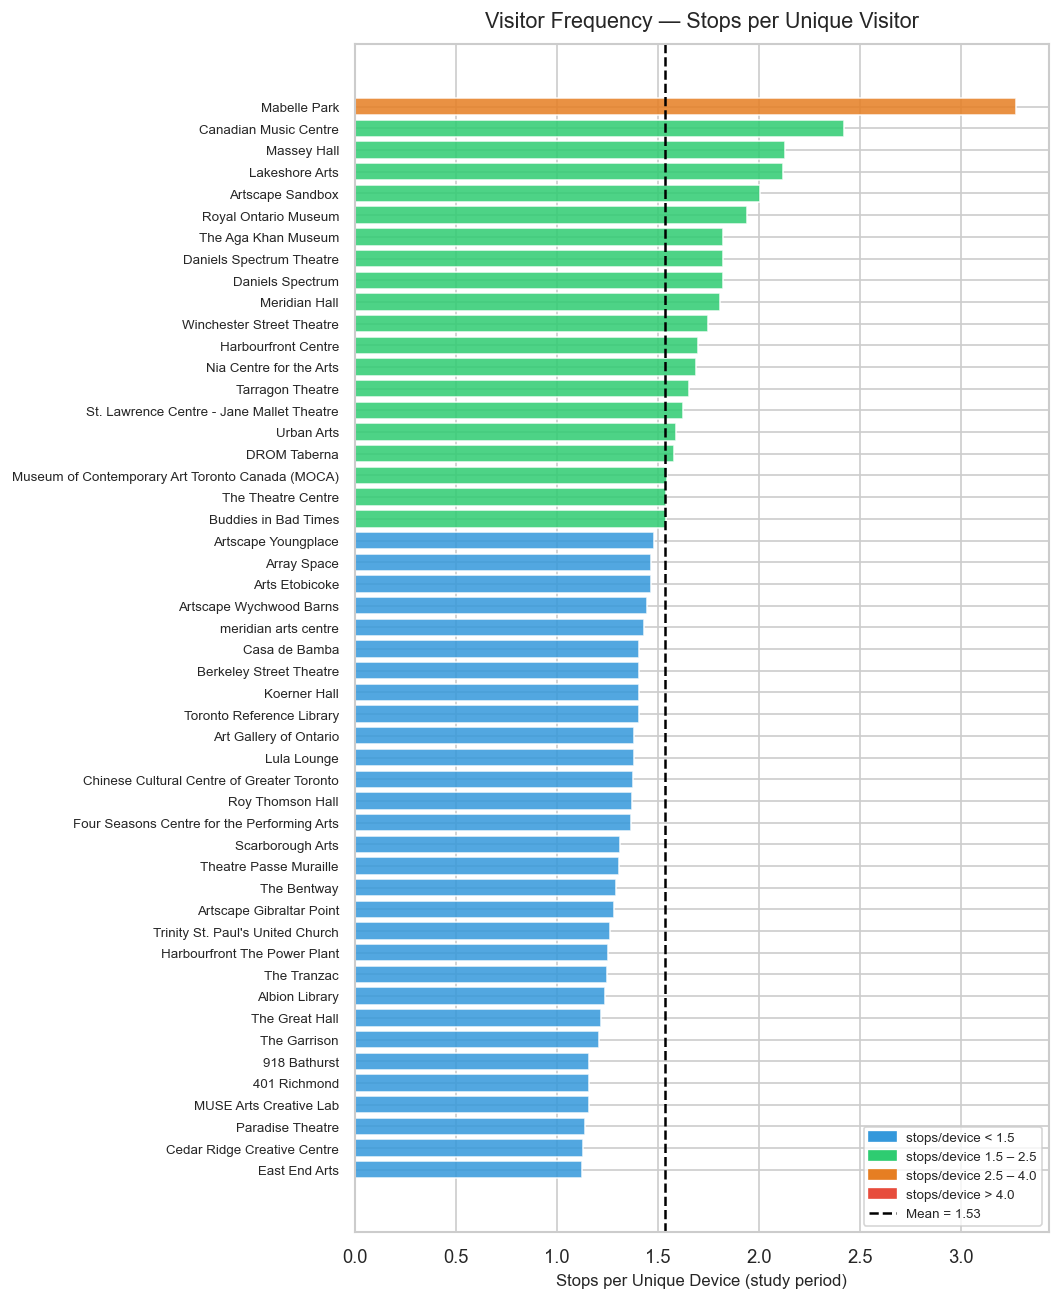

✓ Saved fig04_frequency_buckets.png


In [37]:

# ── fig04_frequency_buckets — stops per unique device, colour-coded by bucket ─
FREQ_BINS   = [0, 1.5, 2.5, 4.0, np.inf]
FREQ_COLORS = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

spd_sorted = venue_totals.sort_values('stops_per_device', ascending=True).reset_index(drop=True)
spd_sorted['freq_bucket'] = pd.cut(
    spd_sorted['stops_per_device'],
    bins=FREQ_BINS,
    labels=['< 1.5', '1.5 – 2.5', '2.5 – 4.0', '> 4.0'],
    right=False
)
bucket_col_map = dict(zip(['< 1.5', '1.5 – 2.5', '2.5 – 4.0', '> 4.0'], FREQ_COLORS))
bar_colors = [bucket_col_map[b] for b in spd_sorted['freq_bucket']]

mean_val = spd_sorted['stops_per_device'].mean()

fig, ax = plt.subplots(figsize=(9, 11))
ax.barh(spd_sorted['venue_name'], spd_sorted['stops_per_device'],
        color=bar_colors, alpha=0.85)
ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_val:.2f}')

# Bucket legend
handles = [mpatches.Patch(color=c, label=f'stops/device {l}')
           for c, l in zip(FREQ_COLORS, ['< 1.5', '1.5 – 2.5', '2.5 – 4.0', '> 4.0'])]
handles.append(plt.Line2D([0], [0], color='black', linestyle='--',
                           label=f'Mean = {mean_val:.2f}'))
ax.legend(handles=handles, fontsize=8, loc='lower right')

ax.set_xlabel('Stops per Unique Device (study period)', fontsize=10)
ax.set_title('Visitor Frequency — Stops per Unique Visitor', fontsize=13, pad=10)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig04_frequency_buckets.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig04_frequency_buckets.png")



---

## Section 5 — Catchment Breadth

Where do visitors come from? The home geohash data maps each visitor's residential neighbourhood to the venue(s) they frequent. Two complementary metrics are used:

- **Unique geohash cells** — how many distinct neighbourhoods contribute visitors (breadth).  
- **HHI (Herfindahl–Hirschman Index)** — how concentrated origins are; HHI → 1 means one dominant neighbourhood, HHI → 0 means a perfectly spread city-wide draw.

The section also examines the geography of **multi-venue hub cells** — the small patches of the city whose residents visit the greatest number of arts venues — and maps them onto the Toronto boundary.

> **Key insight:** The top venues by volume also have the widest catchments; volume and breadth are almost perfectly correlated. Hub cells are tightly clustered in the downtown core and Midtown, confirming that arts engagement is geographically concentrated even among the most engaged residents.


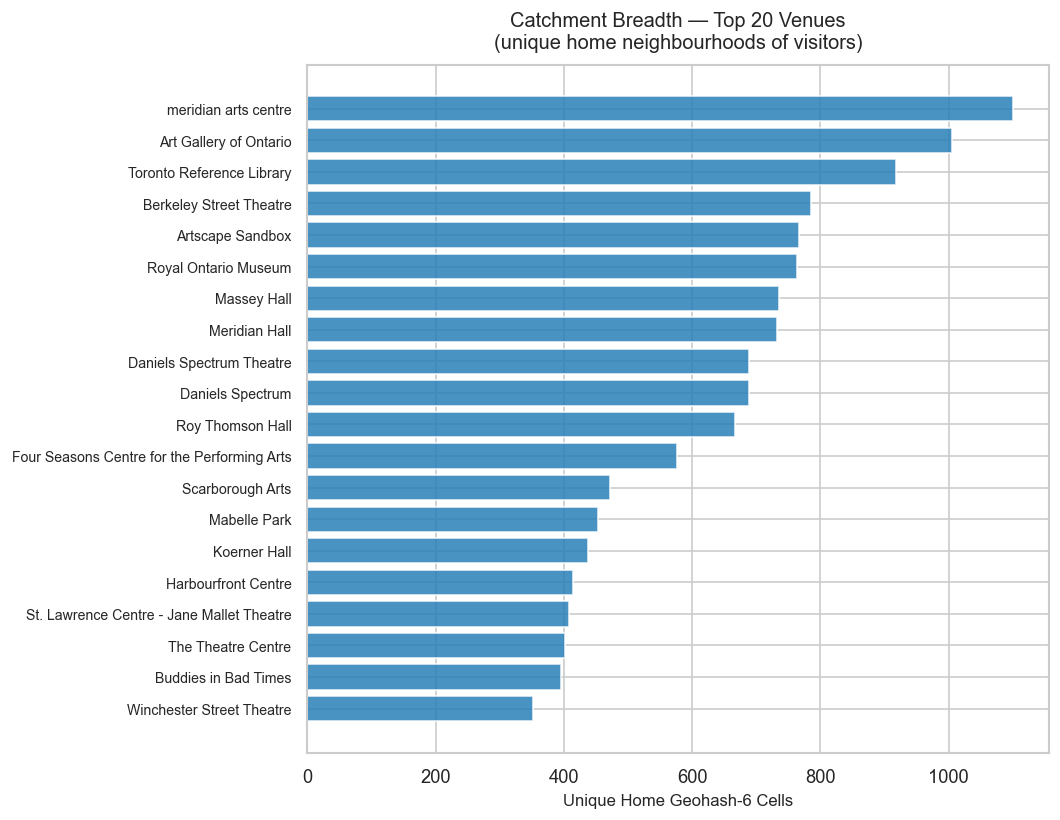

✓ Saved fig05a_catchment_breadth.png


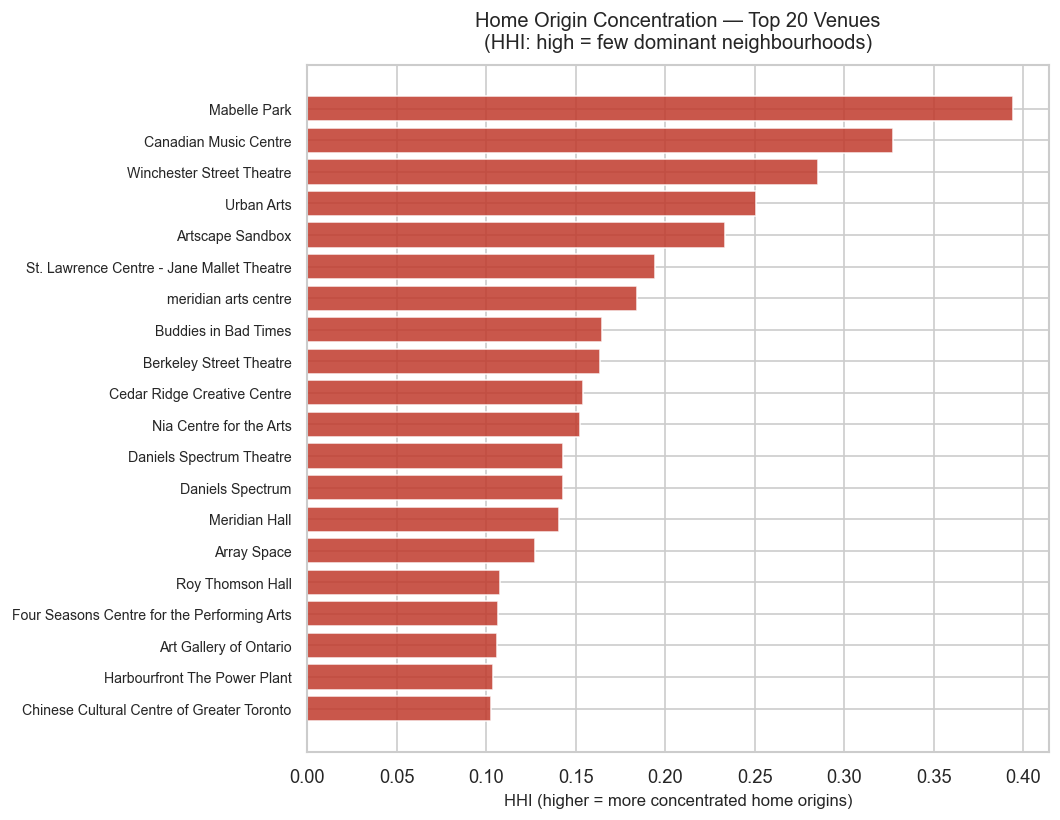

✓ Saved fig05b_catchment_hhi.png


In [38]:

# ── Compute catchment metrics ──────────────────────────────────────────────────
catchment = (
    homes_all.groupby('venue_name').agg(
        unique_geohashes=('home_geohash6', 'nunique'),
        total_devices=('unique_devices', 'sum'),
    )
    .sort_values('unique_geohashes', ascending=False)
    .reset_index()
)

def compute_hhi(group):
    shares = group['unique_devices'] / group['unique_devices'].sum()
    return float((shares ** 2).sum())

hhi_series = homes_all.groupby('venue_name').apply(compute_hhi).reset_index()
hhi_series.columns = ['venue_name', 'hhi']
catchment = catchment.merge(hhi_series, on='venue_name')

# ── fig08a — catchment breadth, top 20 venues ─────────────────────────────────
top20_breadth = catchment.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_breadth['venue_name'][::-1], top20_breadth['unique_geohashes'][::-1],
        color='#2980b9', alpha=0.85)
ax.set_xlabel('Unique Home Geohash-6 Cells', fontsize=10)
ax.set_title('Catchment Breadth — Top 20 Venues\n(unique home neighbourhoods of visitors)',
             fontsize=12, pad=10)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig05a_catchment_breadth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig05a_catchment_breadth.png")

# ── fig08b — HHI concentration, top 20 venues ─────────────────────────────────
top20_hhi = catchment.sort_values('hhi', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_hhi['venue_name'][::-1], top20_hhi['hhi'][::-1],
        color='#c0392b', alpha=0.85)
ax.set_xlabel('HHI (higher = more concentrated home origins)', fontsize=10)
ax.set_title('Home Origin Concentration — Top 20 Venues\n(HHI: high = few dominant neighbourhoods)',
             fontsize=12, pad=10)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig05b_catchment_hhi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig05b_catchment_hhi.png")


In [39]:

# ── Decode geohashes + load Toronto boundary ───────────────────────────────────
unique_ghashes = homes_all['home_geohash6'].dropna().unique()
gh_coords = {}
for gh in unique_ghashes:
    try:
        lat, lon = decode_gh(str(gh))
        gh_coords[gh] = (lat, lon)
    except Exception:
        pass

gta_gdf = gpd.read_file(GEO_PATH)
toronto_gdf = gta_gdf[gta_gdf['CSDNAME'] == 'Toronto'].to_crs(epsg=4326)

# Multi-venue hub counts
hub_counts = homes_all.groupby('home_geohash6').agg(
    n_venues=('venue_name', 'nunique'),
    total_devices=('unique_devices', 'sum')
).sort_values('n_venues', ascending=False).reset_index()

hub_counts['lat'] = hub_counts['home_geohash6'].map(lambda g: gh_coords.get(g, (None, None))[0])
hub_counts['lon'] = hub_counts['home_geohash6'].map(lambda g: gh_coords.get(g, (None, None))[1])
hub_counts_geo = hub_counts.dropna(subset=['lat', 'lon'])

print(f"Decoded {len(gh_coords)}/{len(unique_ghashes)} geohashes")
print(f"Total unique home cells: {len(hub_counts_geo):,}")
print(f"Cells visiting 30+ venues: {(hub_counts_geo['n_venues'] >= 30).sum()}")
print(f"Cells visiting 20+ venues: {(hub_counts_geo['n_venues'] >= 20).sum()}")


Decoded 1213/1213 geohashes
Total unique home cells: 1,213
Cells visiting 30+ venues: 108
Cells visiting 20+ venues: 332


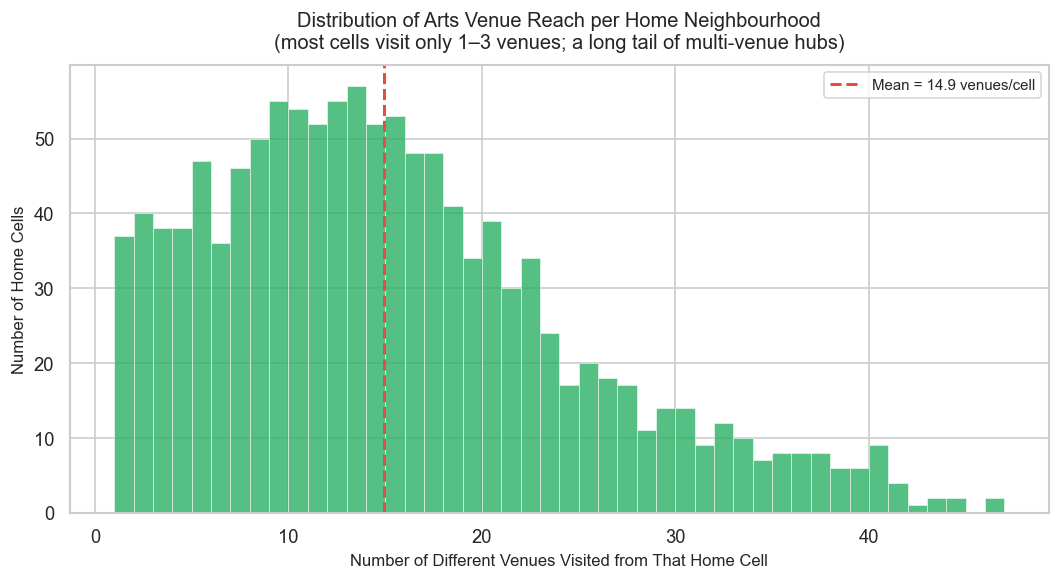

✓ Saved fig05c_hub_distribution.png


In [40]:

# ── fig05c_hub_distribution — how many venues does each home cell visit? ────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(hub_counts_geo['n_venues'],
        bins=range(1, hub_counts_geo['n_venues'].max() + 2),
        color='#27ae60', alpha=0.78, edgecolor='white', linewidth=0.4)
mean_v = hub_counts_geo['n_venues'].mean()
ax.axvline(mean_v, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_v:.1f} venues/cell')
ax.set_xlabel('Number of Different Venues Visited from That Home Cell', fontsize=10)
ax.set_ylabel('Number of Home Cells', fontsize=10)
ax.set_title('Distribution of Arts Venue Reach per Home Neighbourhood\n'
             '(most cells visit only 1–3 venues; a long tail of multi-venue hubs)',
             fontsize=12, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig05c_hub_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig05c_hub_distribution.png")


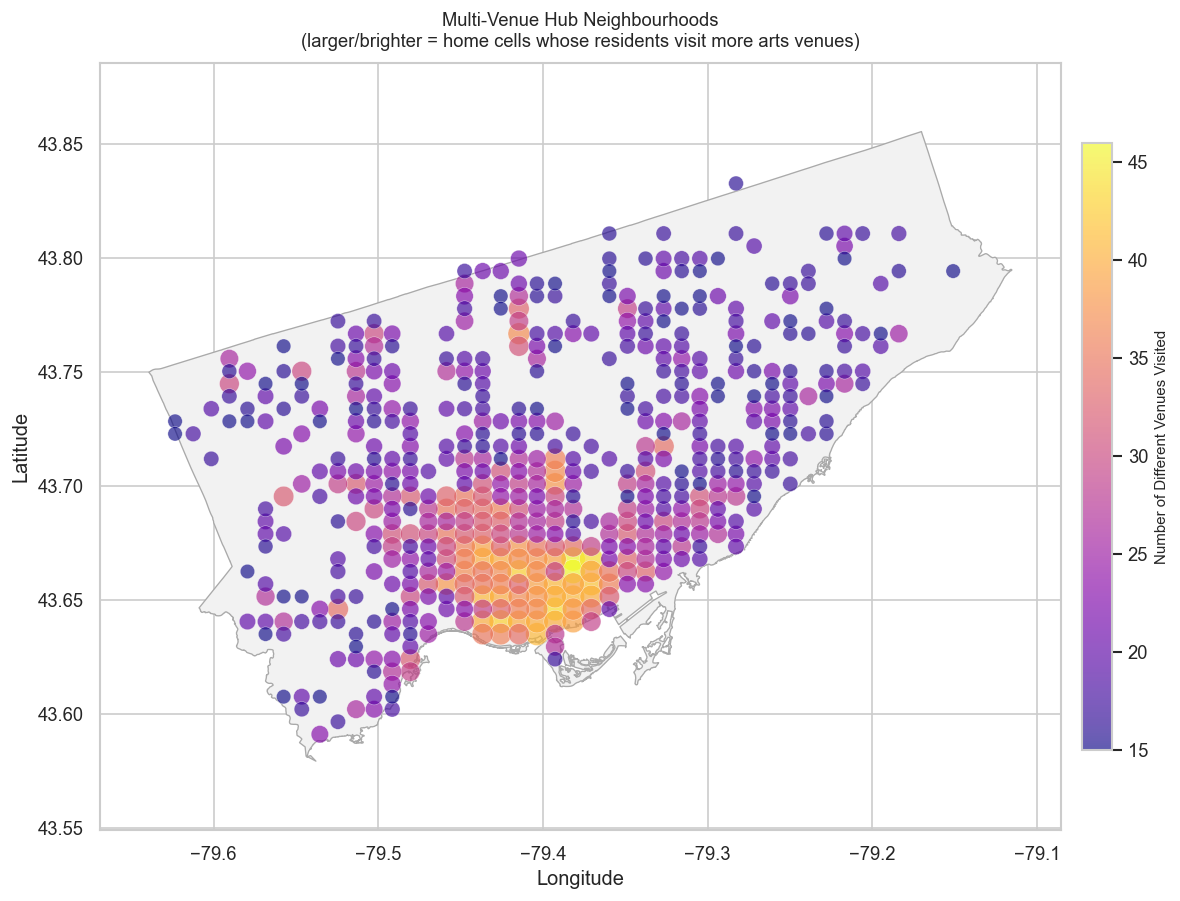

✓ Saved fig05d_hub_map.png


In [41]:

# ── fig05d_hub_map — multi-venue hub neighbourhoods on Toronto boundary ─────────
hubs_plot = hub_counts_geo[hub_counts_geo["n_venues"] >= 15].copy()
max_n = hubs_plot['n_venues'].max()

fig, ax = plt.subplots(figsize=(10, 10))
toronto_gdf.plot(ax=ax, color='#f2f2f2', edgecolor='#aaaaaa', linewidth=0.8)

sc = ax.scatter(
    hubs_plot['lon'], hubs_plot['lat'],
    s=10 + 200 * (hubs_plot['n_venues'] / max_n),
    c=hubs_plot['n_venues'],
    cmap='plasma',
    alpha=0.65,
    linewidths=0.3,
    edgecolors='white',
    zorder=3
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Number of Different Venues Visited', fontsize=9)

ax.set_title('Multi-Venue Hub Neighbourhoods\n'
             '(larger/brighter = home cells whose residents visit more arts venues)',
             fontsize=11, pad=10)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
minx, miny, maxx, maxy = toronto_gdf.total_bounds
margin = 0.03
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig05d_hub_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig05d_hub_map.png")



---

## Section 6 — Travel Distance

Combining visitor home geohash coordinates with venue lat/lon (from the TAC list) allows us to estimate crow-flies travel distance for each visit. Distances are bucketed into three zones: walkable (<1.2 km), driveable/transit (1.2–10 km), and regional (>10 km).

- **fig11** is a stacked horizontal bar chart, one bar per venue, sorted by walkable fraction. It quickly shows which venues are truly neighbourhood institutions vs. which draw city-wide or regional audiences.

> **Key insight:** The sector is overwhelmingly local — median travel distance is around 2 km. A small cohort of major destination venues (Aga Khan Museum, Scarborough Arts) pull from across the city; the majority serve audiences within a transit or cycling trip.


In [42]:

# ── Build home→venue distance dataset ─────────────────────────────────────────
homes_geo = homes_all.copy()
homes_geo['lat'] = homes_geo['home_geohash6'].map(lambda g: gh_coords.get(g, (None, None))[0])
homes_geo['lon'] = homes_geo['home_geohash6'].map(lambda g: gh_coords.get(g, (None, None))[1])
homes_geo = homes_geo.dropna(subset=['lat', 'lon'])
homes_with_loc = homes_geo.merge(venue_loc, on='venue_name', suffixes=('_home', '_venue'))

def crow_flies_km(row):
    return geodesic(
        (row['lat_home'], row['lon_home']),
        (row['lat_venue'], row['lon_venue'])
    ).km

homes_with_loc['dist_km'] = homes_with_loc.apply(crow_flies_km, axis=1)
homes_with_loc['dist_bucket'] = pd.cut(
    homes_with_loc['dist_km'],
    bins=[0, 1.2, 10, np.inf],
    labels=['Walk  (<1.2 km)', 'Drive  (1.2–10 km)', 'Beyond  (>10 km)']
)

# Per-venue percentage breakdown
venue_dist_pcts = {}
for venue, grp in homes_with_loc.groupby('venue_name'):
    total = grp['unique_devices'].sum()
    bp = (
        grp.groupby('dist_bucket', observed=True)['unique_devices'].sum() / total * 100
    ).reindex(['Walk  (<1.2 km)', 'Drive  (1.2–10 km)', 'Beyond  (>10 km)']).fillna(0)
    venue_dist_pcts[venue] = bp.to_dict()

dist_stacked = pd.DataFrame(venue_dist_pcts).T.rename(columns={
    'Walk  (<1.2 km)': 'pct_walk',
    'Drive  (1.2–10 km)': 'pct_drive',
    'Beyond  (>10 km)': 'pct_beyond'
})
dist_stacked = dist_stacked.sort_values('pct_walk', ascending=True)

print(f"Distance data for {len(dist_stacked)} venues computed ✓")
print(f"Median walk%: {dist_stacked['pct_walk'].median():.0f}%  |  "
      f"drive%: {dist_stacked['pct_drive'].median():.0f}%  |  "
      f"beyond%: {dist_stacked['pct_beyond'].median():.0f}%")


Distance data for 49 venues computed ✓
Median walk%: 39%  |  drive%: 46%  |  beyond%: 14%


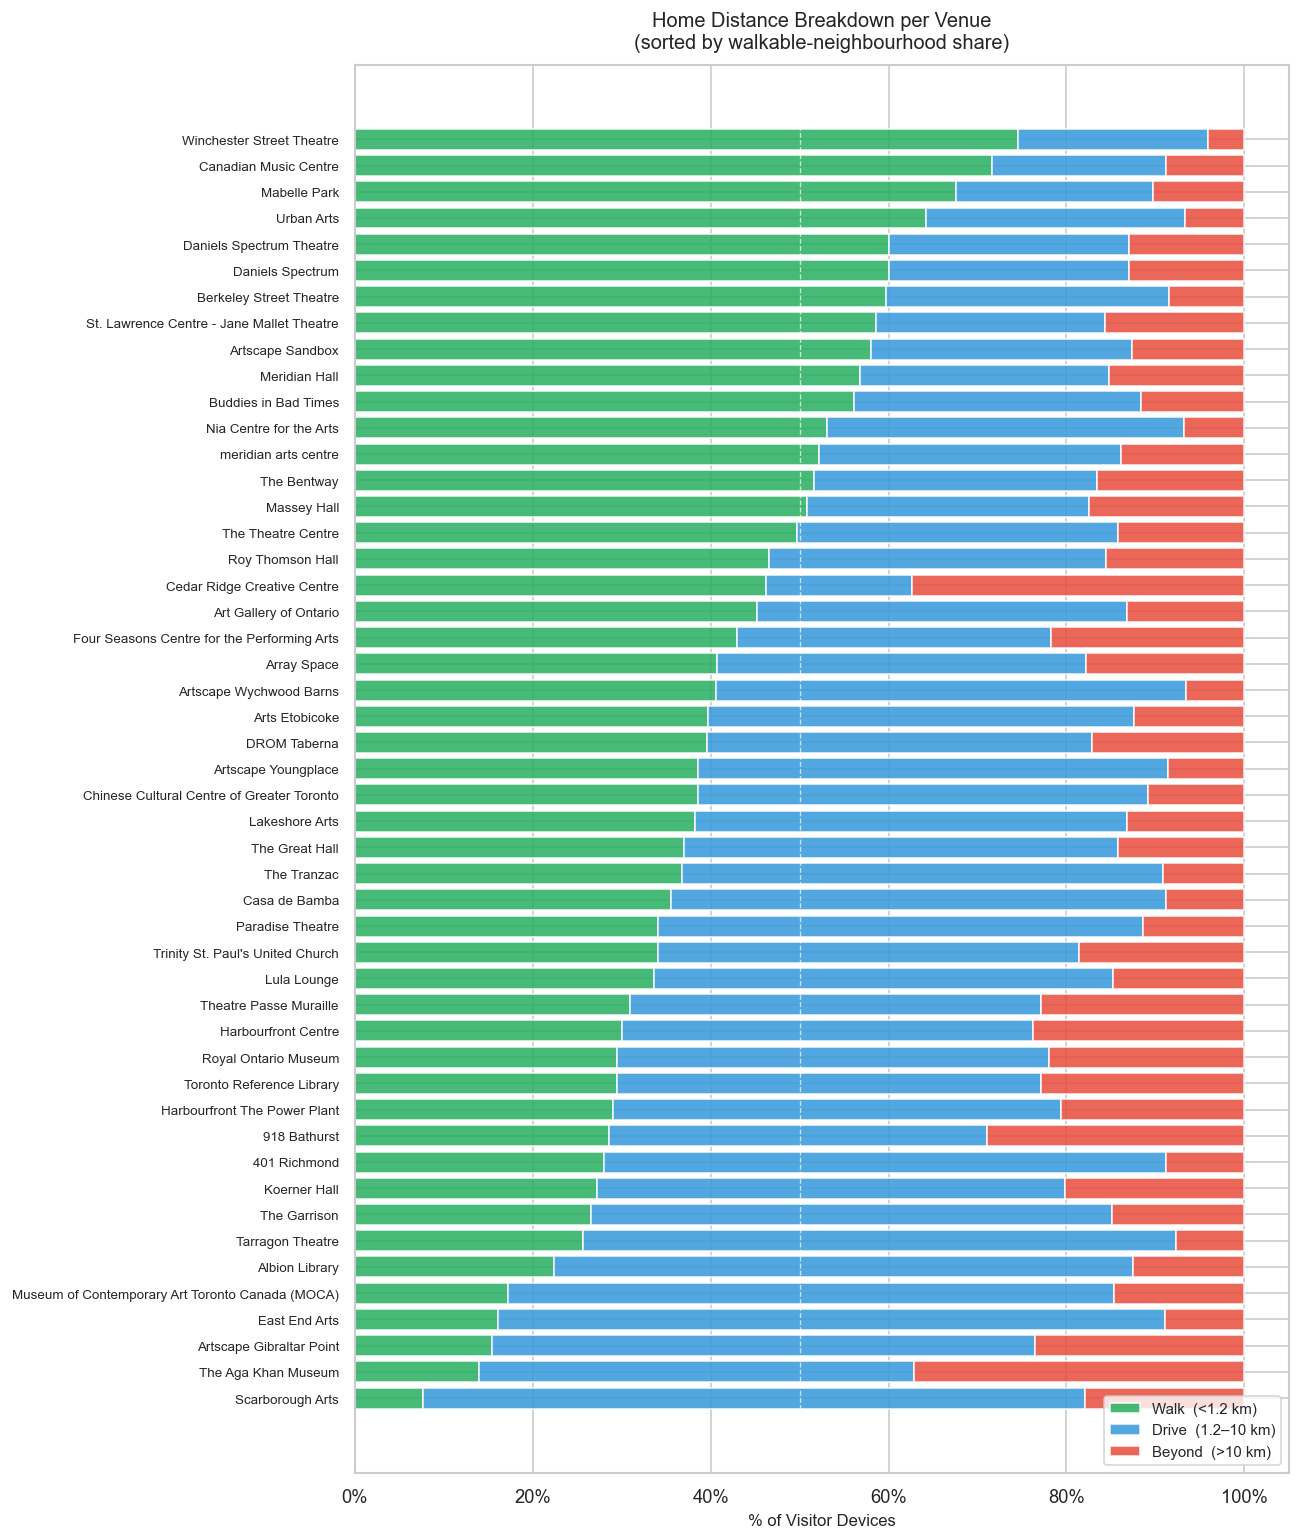

✓ Saved fig06_distance_buckets.png


In [43]:

# ── fig06_distance_buckets — stacked bar per venue, sorted by walk fraction ────
BUCKET_COLORS  = ['#27ae60', '#3498db', '#e74c3c']
BUCKET_LABELS  = ['Walk  (<1.2 km)', 'Drive  (1.2–10 km)', 'Beyond  (>10 km)']

fig, ax = plt.subplots(figsize=(11, 13))
left = np.zeros(len(dist_stacked))

for col, color, label in zip(['pct_walk', 'pct_drive', 'pct_beyond'],
                              BUCKET_COLORS, BUCKET_LABELS):
    ax.barh(dist_stacked.index, dist_stacked[col], left=left,
            color=color, label=label, alpha=0.85)
    left += dist_stacked[col].values

ax.set_xlabel('% of Visitor Devices', fontsize=10)
ax.set_title('Home Distance Breakdown per Venue\n'
             '(sorted by walkable-neighbourhood share)',
             fontsize=12, pad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='lower right', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.axvline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig06_distance_buckets.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved fig06_distance_buckets.png")



---

## Section 7 — Networks of Venues

This section asks: do different arts venues share their audiences? Two approaches visualise this:

1. A **cosine similarity heatmap** — venues are rows/columns; the colour encodes how similar their visitor home-origin profiles are. Venues are sorted by hierarchical clustering so similar venues sit adjacent to each other.  
2. A **network graph** — venues are nodes (sized by total visits), and edges connect pairs whose cosine similarity exceeds a threshold, giving a spatial sense of audience clustering.

**Technical note:** The original exploratory analysis used geohash-6 resolution (~1.2 × 0.6 km cells). With ~50 venues and ~1,200 home cells, many cells are sparsely populated, making similarity estimates noisy. Here we aggregate to **geohash-5** resolution (~5 × 5 km cells), giving more stable counts at the cost of some spatial precision. This should produce cleaner and more interpretable similarity clusters.

> **Key insight:** Audience similarity is generally sparse — most venues serve genuinely distinct neighbourhoods. However, geographic "sibling pairs" are visible: venues co-located in the downtown entertainment district share audiences, while community arts venues on the city's edges show little overlap with each other or with central institutions.


In [4]:

# ── Aggregate homes to geohash-5 ──────────────────────────────────────────────
homes_gh5 = homes_all.copy()
homes_gh5['home_geohash5'] = homes_gh5['home_geohash6'].apply(lambda g: truncate_gh(str(g), 5))

homes_gh5_agg = (
    homes_gh5.groupby(['venue_name', 'home_geohash5'], as_index=False)['unique_devices']
    .sum()
)

print(f"Geohash-6 unique cells: {homes_all['home_geohash6'].nunique()}")
print(f"Geohash-5 unique cells: {homes_gh5_agg['home_geohash5'].nunique()}")
print(f"Rows after gh5 aggregation: {len(homes_gh5_agg):,}")


Geohash-6 unique cells: 1213
Geohash-5 unique cells: 56
Rows after gh5 aggregation: 2,038


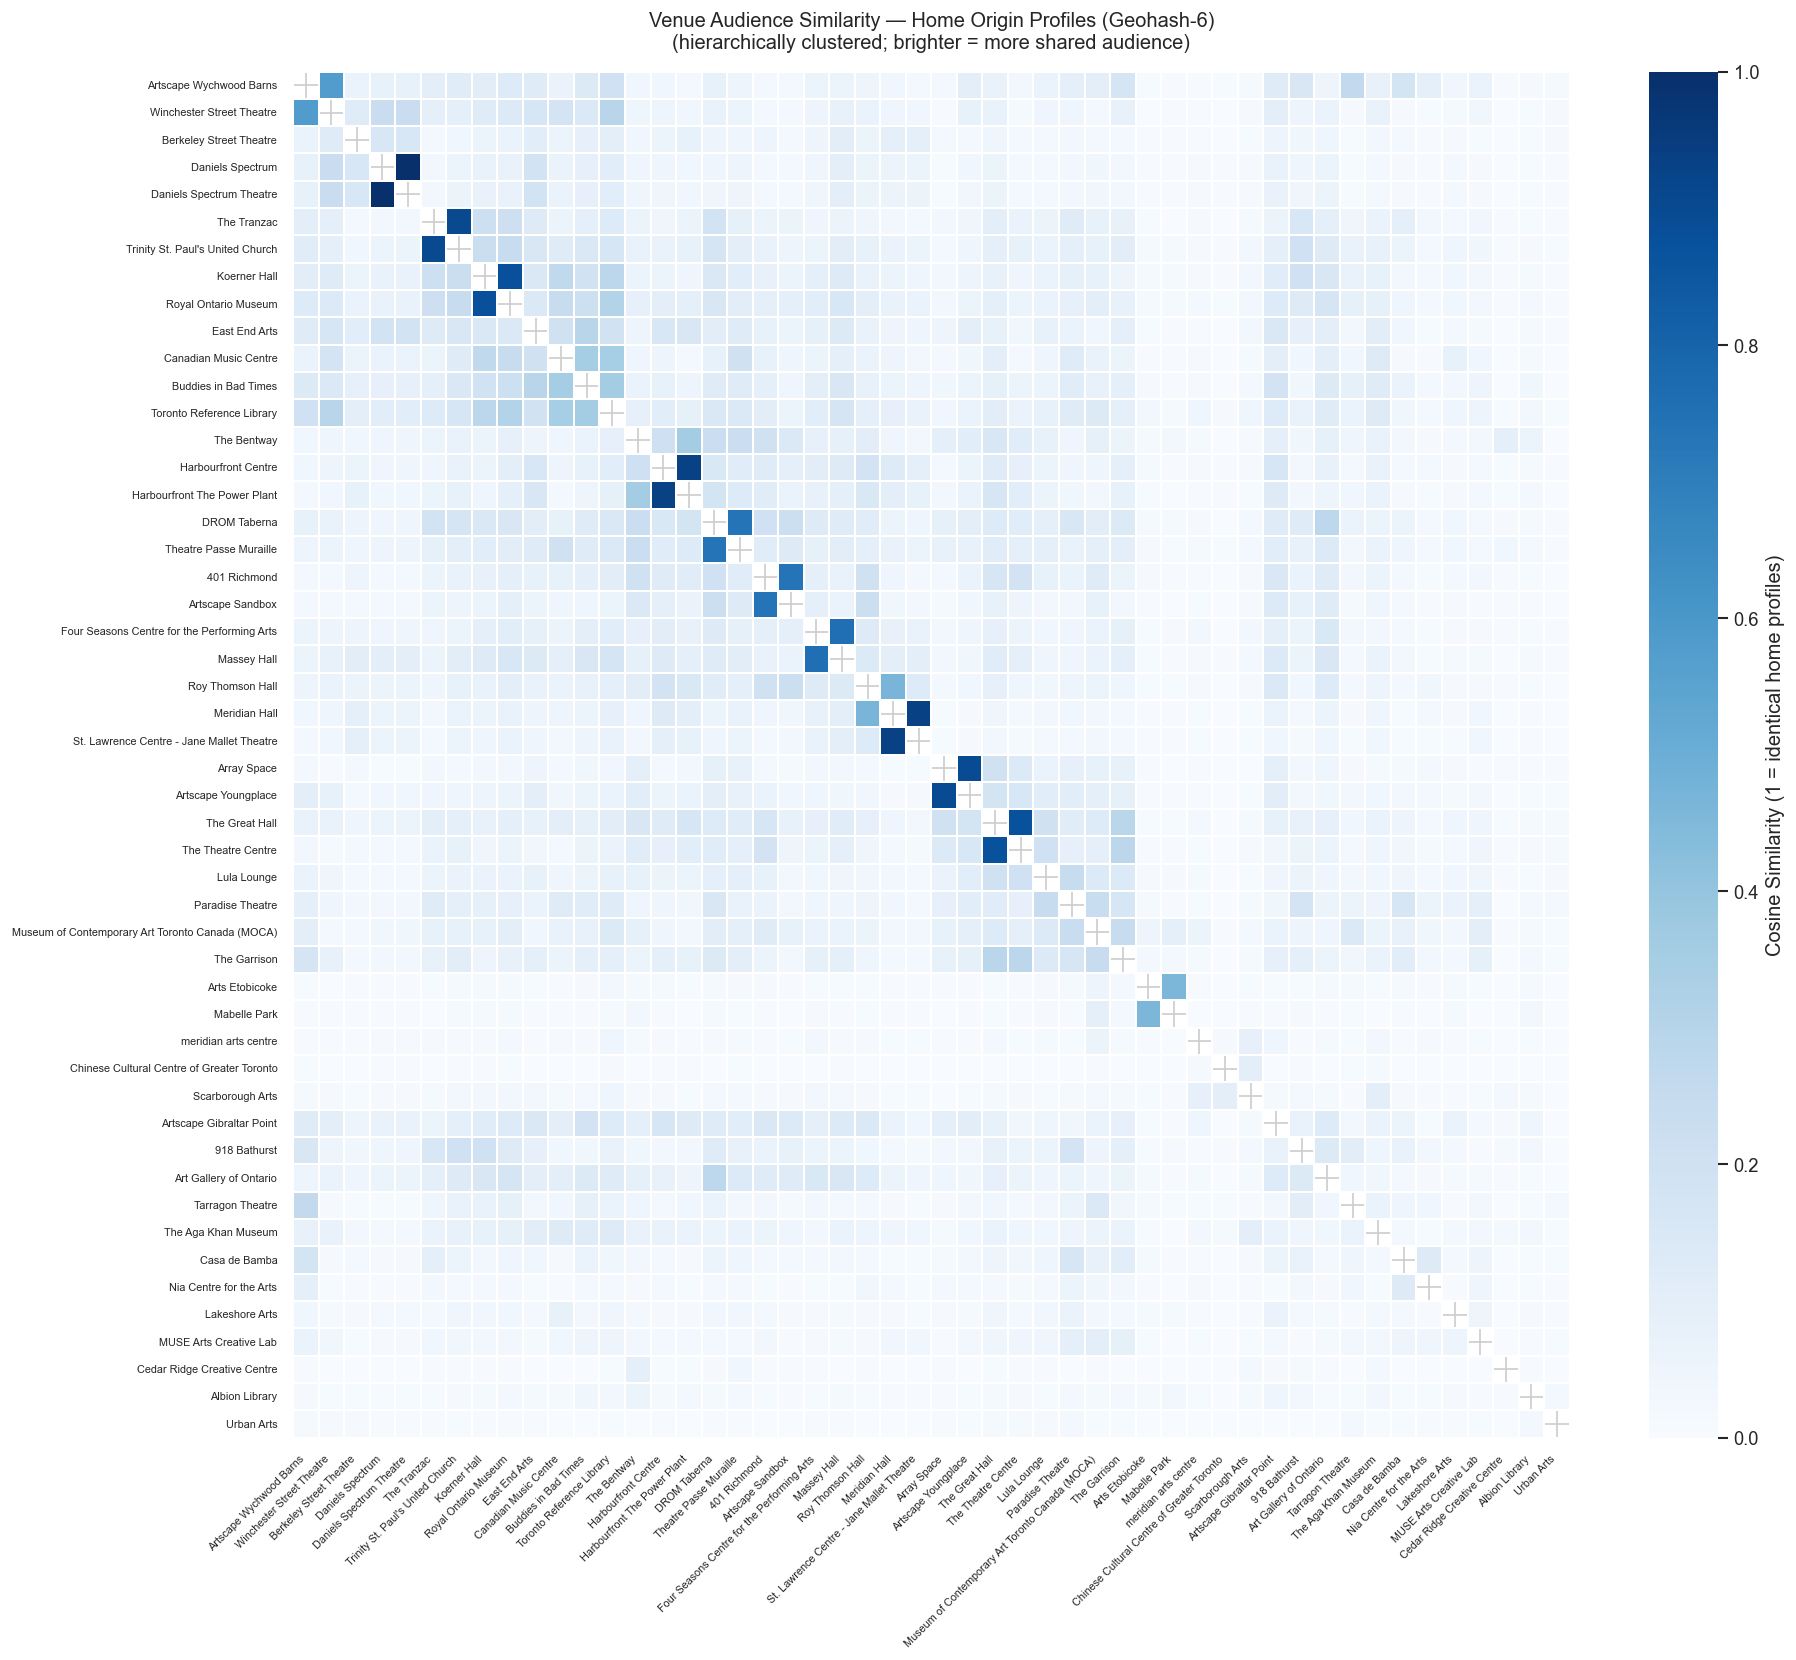

Geohash-6 unique cells: 1213
Venues in matrix:       50
Network avg similarity: 0.064  |  median: 0.042

Top 10 most similar venue pairs (geohash-6):
                                    venue_a                                   venue_b  similarity
                           Daniels Spectrum                  Daniels Spectrum Theatre    1.000000
                        Harbourfront Centre              Harbourfront The Power Plant    0.932262
                              Meridian Hall St. Lawrence Centre - Jane Mallet Theatre    0.931215
                                The Tranzac          Trinity St. Paul's United Church    0.905843
                                Array Space                       Artscape Youngplace    0.894890
                               Koerner Hall                      Royal Ontario Museum    0.877575
                             The Great Hall                        The Theatre Centre    0.873918
Four Seasons Centre for the Performing Arts                       

In [12]:

# ── Geohash-6 cosine similarity matrix ────────────────────────────────────────
# Builds venue × venue cosine similarity from home_geohash6 origin profiles.
# 1,213 cells → fine-grained, venue-level differentiation.

homes_gh6_agg = (
    homes_all.groupby(['venue_name', 'home_geohash6'], as_index=False)['unique_devices']
    .sum()
)

homes_pivot6 = homes_gh6_agg.pivot_table(
    index='venue_name', columns='home_geohash6',
    values='unique_devices', fill_value=0
)

homes_norm6 = normalize(homes_pivot6.values, norm='l2')
cos_sim6    = cosine_similarity(homes_norm6)
cos_sim6_df = pd.DataFrame(cos_sim6, index=homes_pivot6.index, columns=homes_pivot6.index)

# Hierarchical clustering order
dist_matrix6 = np.clip(1 - cos_sim6_df.values, 0, 1)
np.fill_diagonal(dist_matrix6, 0)
link6       = linkage(squareform(dist_matrix6), method='ward')
order6      = leaves_list(link6)
cos_sorted6 = cos_sim6_df.iloc[order6, order6]

mask_eye6 = np.eye(len(cos_sorted6), dtype=bool)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cos_sorted6, ax=ax,
    cmap='Blues',
    mask=mask_eye6,
    xticklabels=True, yticklabels=True,
    linewidths=0.2, linecolor='white',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Cosine Similarity (1 = identical home profiles)'}
)
ax.set_title('Venue Audience Similarity — Home Origin Profiles (Geohash-6)\n'
             '(hierarchically clustered; brighter = more shared audience)',
             fontsize=12, pad=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=6.5)
plt.yticks(fontsize=6.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig07a_cosine_similarity_gh6.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Report top similar pairs ───────────────────────────────────────────────────
pairs6 = []
n6 = len(cos_sim6_df)
for i in range(n6):
    for j in range(i + 1, n6):
        pairs6.append((cos_sim6_df.index[i], cos_sim6_df.columns[j], cos_sim6[i, j]))
pairs6_df = pd.DataFrame(pairs6, columns=['venue_a', 'venue_b', 'similarity'])
pairs6_df = pairs6_df.sort_values('similarity', ascending=False).reset_index(drop=True)

off_diag = cos_sim6_df.values[~mask_eye6]
print(f"Geohash-6 unique cells: {homes_gh6_agg['home_geohash6'].nunique()}")
print(f"Venues in matrix:       {n6}")
print(f"Network avg similarity: {off_diag.mean():.3f}  |  median: {np.median(off_diag):.3f}")
print("\nTop 10 most similar venue pairs (geohash-6):")
print(pairs6_df.head(10).to_string(index=False))
print("\n✓ Saved fig07a_cosine_similarity_gh6.png")
